El algoritmo de k vecinos más cercanos (KNN) es un método de aprendizaje supervisado (no parametrico) utilizado para clasificación y regresión. Su funcionamiento se basa en la premisa de que instancias similares tienden a agruparse en el espacio de características. Funciona bajo el principio "Dime con quien te juntas y te diré quien eres"

Los pasos del algoritmo son los siguientes

- Entrada de datos:

Se inicia con un conjunto de datos de entrenamiento que contiene ejemplos etiquetados, es decir, instancias con características conocidas y sus respectivas clases o valores.

- Selección de parámetros:

El usuario debe elegir el valor de "k", que representa el número de vecinos más cercanos que se tendrán en cuenta para tomar una decisión. K es un hiperparámetro

- Cálculo de distancias:

Para una nueva instancia de entrada, el algoritmo calcula la distancia entre esta instancia y todas las instancias de entrenamiento utilizando una medida de distancia, comúnmente la distancia euclidiana o de manhattan (pero pueden usarse otras)

$d(x_i, x_{i ′}) = \sum^{p}_{j=1} (x_{ij}−x_{i′j})^2 = || x_i−x_{i′}||^2$

- Identificación de vecinos más cercanos:

Se seleccionan los "k" vecinos más cercanos según la distancia calculada. 
En el caso de clasificación, se realiza una votación entre los vecinos para determinar la clase más común (moda). En regresión, se calcula el promedio de los valores para obtener la predicción final.

<img src="kvecinos.png">

En clasificación se requiere una mayoría superior al 50 %,lo que funciona principalmente cuando solohay dos categorías,
sin embargo para mas categorías esto no es necesario. Si tenemos 4 categorias puede asignar una etiqueta de clase con un voto superior
al 25 %.


El algoritmo KNN es sencillo pero puede ser sensible a la elección de la métrica de distancia y al valor de "k". Definir k puede llevar a un ajuste excesivo o insuficiente. Los valores más bajos de k pueden tener una varianza alta, pero un sesgo bajo, y los valores más grandes de k pueden generar un sesgo alto y una varianza más baja (trade off varianza sesgo)

 Si bien es ampliamente utilizado debido a su simplicidad y capacidad para adaptarse a patrones no lineales en los datos. el algoritmo KNN también forma parte de una familia de modelos de "aprendizaje perezoso", lo que significa que solo almacena un conjunto de datos de entrenamiento en lugar de pasar por una etapa de entrenamiento. Esto también significa que todo el cálculo ocurre cuando se realiza una clasificación o predicción. Dado que depende en gran medida de la memoria para almacenar todos sus datos de entrenamiento, también se lo denomina método de aprendizaje basado en instancias o basado en la memoria.



Debido a que el algoritmo de K vecinos más cercanos está basado en distancias es importante normalizar el conjunto de datos.
A continuación un ejemplo comparando un conjunto de datos normalizado contra uno que no lo está.
<img src="kvecinosnormal.png">

#### Ventajas:

- Fácil de implementar: La logica del algoritmo es sencilla

- Se adapta fácilmente: A medida que se agregan nuevas muestras de entrenamiento, el algoritmo se ajusta para tener en cuenta cualquier dato nuevo, ya que todos los datos de entrenamiento se almacenan en la memoria.

- Pocos hiperparámetros: KNN solo requiere un valor k y una métrica de distancia, que es baja en comparación con otros algoritmos de machine learning.

#### Desventajas:

- Maldición de Dimensionalidad: Funciona mal en conjuntos de datos de alta dimensionalidad.
- Costoso: Dado que KNN es un algoritmo perezoso, ocupa más memoria y almacenamiento de datos en comparación con otros clasificadores
- Sobreajuste: El algoritmo tiende a sobreajustar

### Implementación manual (Fuente:Onel Harrison)

In [49]:
import matplotlib.pyplot as plt
from collections import Counter
import math
import pandas as pd

from sklearn.neighbors import NearestNeighbors,KNeighborsClassifier
import requests
from io import StringIO

from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score,accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

In [2]:


def knn(data, query, k, distance_fn, choice_fn): #conjunto de datos, valor a estimar, numero de vecinos, moda o media
    neighbor_distances_and_indices = []
    
    
    for index, example in enumerate(data):
        # 3.1 calculamos la distancia entre el numero que queremos estimar y cada punto
        distance = distance_fn(example[:-1], query)
        
        # 3.2 Agregamos en una lista el indice del registro asi como la distancia que tiene con el valor a estimar
        neighbor_distances_and_indices.append((distance, index))
    
    # 4. ordenamos con base en la distancia (los primeros elementos tienen la menor distancia con el valor a estimar)
    sorted_neighbor_distances_and_indices = sorted(neighbor_distances_and_indices)
    
    # 5. establecemos el numero de vecinos que queremos utilizar
    k_nearest_distances_and_indices = sorted_neighbor_distances_and_indices[:k]
    
    # 6. tomamos los valores de los  k vecinos mas cercanos
    k_nearest_labels = [data[i][-1] for distance, i in k_nearest_distances_and_indices]
     
    ## 7. calculamos la media de los vecinos (regresion) o la moda(clasificacion)
    return k_nearest_distances_and_indices , choice_fn(k_nearest_labels)

def mean(labels): # funcion de media
    return sum(labels) / len(labels)

def mode(labels): # funcion de moda
    return Counter(labels).most_common(1)[0][0]

def euclidean_distance(point1, point2): # distancia euclidiana
    sum_squared_distance = 0
    for i in range(len(point1)):
        sum_squared_distance += math.pow(point1[i] - point2[i], 2)
    return math.sqrt(sum_squared_distance)


### Usando la función en regresión

In [3]:
reg_data = [
       [65.75, 112.99],
       [71.52, 136.49],
       [69.40, 153.03],
       [68.22, 142.34],
       [67.79, 144.30],
       [68.70, 123.30],
       [69.80, 141.49],
       [70.01, 136.46],
       [67.90, 112.37],
       [66.49, 127.45],
    ]
   


In [4]:
### queremos estimar el numero 66
reg_query = [66]

reg_k_nearest_neighbors, reg_prediction = knn(reg_data, reg_query, k=3, distance_fn=euclidean_distance, choice_fn=mean)
print(reg_k_nearest_neighbors) ### distancia entre el vecino y el punto, indice del vecino
print(reg_prediction) # prediccion

[(0.25, 0), (0.4899999999999949, 9), (1.7900000000000063, 4)]
128.24666666666667


### usando la funcion en clasificación

In [5]:
clf_data = [
       [22, 1],
       [23, 1],
       [21, 1],
       [18, 1],
       [19, 1],
       [25, 0],
       [27, 0],
       [29, 0],
       [31, 0],
       [45, 0],
    ]
    # Question:
    # Given the data we have, does a 33 year old like pineapples on their pizza?
clf_query = [33]
clf_k_nearest_neighbors, clf_prediction = knn(clf_data, clf_query, k=3, distance_fn=euclidean_distance, choice_fn=mode)
print(clf_k_nearest_neighbors) ### distancia entre el vecino y el punto, indice del vecino
print(clf_prediction) # prediccion

[(2.0, 8), (4.0, 7), (6.0, 6)]
0


PASO A PASO DE LA FUNCIÓN

In [6]:
### DEFINIMOS DATOS
data = [
       [65.75, 112.99],
       [71.52, 136.49],
       [69.40, 153.03],
       [68.22, 142.34],
       [67.79, 144.30],
       [68.70, 123.30],
       [69.80, 141.49],
       [70.01, 136.46],
       [67.90, 112.37],
       [66.49, 127.45],
    ]

In [7]:
### SE CALCULAN DISTANCIAS ENTRE EL PUNTO Y CADA REGISTRO DEL CONJUNTO DE DATOS
test=[66]
neighbor_distances_and_indices = []
for index, example in enumerate(data):
    print(index)
    print(example)
    print(example[:-1])
    distance=euclidean_distance(example[:-1], test)
    print(euclidean_distance(example[:-1], test))
    print(".....")
    neighbor_distances_and_indices.append((distance, index)) ### SE AGREGAN LAS DISTANCIAS E INDICES EN UNA LISTA

neighbor_distances_and_indices

0
[65.75, 112.99]
[65.75]
0.25
.....
1
[71.52, 136.49]
[71.52]
5.519999999999996
.....
2
[69.4, 153.03]
[69.4]
3.4000000000000057
.....
3
[68.22, 142.34]
[68.22]
2.219999999999999
.....
4
[67.79, 144.3]
[67.79]
1.7900000000000063
.....
5
[68.7, 123.3]
[68.7]
2.700000000000003
.....
6
[69.8, 141.49]
[69.8]
3.799999999999997
.....
7
[70.01, 136.46]
[70.01]
4.010000000000005
.....
8
[67.9, 112.37]
[67.9]
1.9000000000000057
.....
9
[66.49, 127.45]
[66.49]
0.4899999999999949
.....


[(0.25, 0),
 (5.519999999999996, 1),
 (3.4000000000000057, 2),
 (2.219999999999999, 3),
 (1.7900000000000063, 4),
 (2.700000000000003, 5),
 (3.799999999999997, 6),
 (4.010000000000005, 7),
 (1.9000000000000057, 8),
 (0.4899999999999949, 9)]

In [8]:
sorted_neighbor_distances_and_indices = sorted(neighbor_distances_and_indices)
print(sorted_neighbor_distances_and_indices) ### ORDENAMOS DE MENOR A MAYOR LAS DISTANCIAS

[(0.25, 0), (0.4899999999999949, 9), (1.7900000000000063, 4), (1.9000000000000057, 8), (2.219999999999999, 3), (2.700000000000003, 5), (3.4000000000000057, 2), (3.799999999999997, 6), (4.010000000000005, 7), (5.519999999999996, 1)]


In [9]:
### NOS QUEDAMOS CON LOS 3 VECINOS MAS CERCANOS
k=3
k_nearest_distances_and_indices = sorted_neighbor_distances_and_indices[:k]
print(k_nearest_distances_and_indices)

[(0.25, 0), (0.4899999999999949, 9), (1.7900000000000063, 4)]


In [10]:
#### CON BASE EN EL INDICE REGRESAMOS LOS VALORES DE Y PARA CADA VECINO
k_nearest_labels = [data[i][-1] for distance, i in k_nearest_distances_and_indices]
k_nearest_labels

[112.99, 127.45, 144.3]

In [11]:
mean(k_nearest_labels) ### SE HACE EL PROMEDIO DE LOS VECINOS ANTERIORES

128.24666666666667

### VISUALIZACION DE RESULTADOS

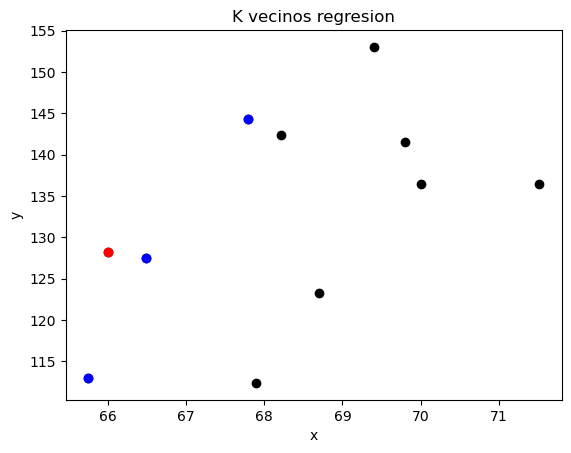

In [12]:
data = [
    [65.75, 112.99],
    [71.52, 136.49],
    [69.40, 153.03],
    [68.22, 142.34],
    [67.79, 144.30],
    [68.70, 123.30],
    [69.80, 141.49],
    [70.01, 136.46],
    [67.90, 112.37],
    [66.49, 127.45],[66,128.24666666666667]
]

# Separar los datos en dos listas: una para las coordenadas x y otra para las coordenadas y
x = [point[0] for point in data]
y = [point[1] for point in data]

# Identificar los puntos con asterisco y el punto [66,128.24666666666667]
vecinos_cercanos = [0, 4, 9]
prediction = [x.index(66), y.index(128.24666666666667)]

# Crear la gráfica
plt.scatter(x, y, color='black')  # Todos los puntos en azul

# Puntos con asterisco en rojo
for idx in vecinos_cercanos:
    plt.scatter(x[idx], y[idx], color='blue')

# Punto [66,128.24666666666667] en rojo
plt.scatter(x[prediction[0]], y[prediction[1]], color='red')

# Etiquetas y título
plt.xlabel('x')
plt.ylabel('y')
plt.title('K vecinos regresion')

# Mostrar la gráfica
plt.show()

### INTRODUCCION A SISTEMAS DE RECOMENDACIÓN

In [30]:
### CARGAMOS SET DE DATOS
df= pd.read_csv("tmdb_5000_movies.csv")

In [31]:
df["title"]=df["title"].str.replace('\W', '', regex=True) ### QUITAMOS REGISTROS CON CARACTERES ESPECIALES

In [32]:
df.head(5)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",PiratesoftheCaribbeanAtWorldsEnd,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,TheDarkKnightRises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",JohnCarter,6.1,2124


In [33]:
# queremos extraer el primer genero de la columna genre

In [34]:
import json
import pandas as pd

# Datos de ejemplo
data =df.genres

# Convertir datos de cadena JSON a lista de diccionarios
genres_list = [json.loads(genre_str) for genre_str in data]

# Extraer el primer valor de género de cada fila
first_genre_values = [genres[0]['name'] if genres else None for genres in genres_list]

# Crear un DataFrame tabular
df_genres = pd.DataFrame({'First Genre': first_genre_values})

# Imprimir el DataFrame
print(df_genres)

      First Genre
0          Action
1       Adventure
2          Action
3          Action
4          Action
...           ...
4798       Action
4799       Comedy
4800       Comedy
4801         None
4802  Documentary

[4803 rows x 1 columns]


In [35]:
df = pd.concat([df,df_genres],axis=1) ### concatenamos los nuevos valores

In [36]:
df=df[["title","vote_average","First Genre"]]# nos quedamos unico con genero , nombre y votación

In [37]:
df.columns=["title","vote_average","genre"] # renombramos columnas

In [38]:
dummies_genre=pd.get_dummies(df["genre"],prefix="genre").replace(True,1).replace(False,0) # convertimos genero a dummy

In [39]:
df = pd.concat([df,dummies_genre],axis=1).drop(columns="genre") # eliminamos la variable original de genero

In [40]:
df.tail(5)

,title,vote_average,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Family,...,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_TV Movie,genre_Thriller,genre_War,genre_Western
4798,ElMariachi,6.6,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4799,Newlyweds,5.9,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4800,SignedSealedDelivered,7.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4801,ShanghaiCalling,5.7,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4802,MyDatewithDrew,6.3,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [41]:
### vemos cuantas peliculas por genero tenemos
for i in df.drop(columns=["title","vote_average"]).columns:
    print(i,df[i].sum())

genre_Action 754
genre_Adventure 339
genre_Animation 123
genre_Comedy 1042
genre_Crime 195
genre_Documentary 89
genre_Drama 1207
genre_Family 56
genre_Fantasy 117
genre_Foreign 2
genre_History 25
genre_Horror 300
genre_Music 34
genre_Mystery 41
genre_Romance 106
genre_Science Fiction 96
genre_TV Movie 4
genre_Thriller 194
genre_War 24
genre_Western 27


In [42]:
df.to_csv("clean_movies.csv",index=False) # guardamos el data set limpio

In [43]:
df = pd.read_csv("clean_movies.csv") # lo cargamos nuevamente

In [44]:
### fijamos el titulo como indice y normalizamos variable
df.set_index('title', inplace=True)

# Normalizar los datos
df_normalized = df.copy()
df_normalized["vote_average"] = (df_normalized["vote_average"] - min(df_normalized["vote_average"])) / (max(df_normalized["vote_average"]) - min(df_normalized["vote_average"]))



In [45]:
# Entrenar el modelo KNN con 5 vecinos
knn_model = NearestNeighbors(n_neighbors=5,metric='cosine')
knn_model.fit(df_normalized)

NearestNeighbors(metric='cosine')

In [46]:
### creamos funcion de prediccion
def get_movie_recommendations(movie_title):
    # Encontrar películas más cercanas usando KNN
    movie_index = df.index.get_loc(movie_title) ### tomamos el indice en el df dado el nombre de la pelicula
    distances, indices = knn_model.kneighbors([df_normalized.iloc[movie_index]]) ### buscamos los 5 vecinos mas cercanos para esa pelicula

    # Imprimir las recomendaciones
    print(f"Recomendaciones para '{movie_title}':")
    for i, index in enumerate(indices[0][0:], 1): ### imprimimos los vecinos
        print(i," ",df.index[index])

# Obtener recomendaciones para una película específica
get_movie_recommendations('PiratesoftheCaribbeanAtWorldsEnd')

Recomendaciones para 'PiratesoftheCaribbeanAtWorldsEnd':
1   StargateTheArkofTruth
2   MobyDick
3   Divergent
4   TwoBrothers
5   MasterandCommanderTheFarSideoftheWorld


C:\Users\Sergio.Chavez\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [47]:
get_movie_recommendations('Spectre') ### valuamos en otra pelicula

Recomendaciones para 'Spectre':
1   TheForbiddenKingdom
2   TheQuickandtheDead
3   Warcraft
4   ThisIstheEnd
5   55DaysatPeking


C:\Users\Sergio.Chavez\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [48]:
get_movie_recommendations('ElMariachi') ### valuamos en otra pelicula

Recomendaciones para 'ElMariachi':
1   TheLimey
2   SaintsandSoldiers
3   RED
4   AllIsLost
5   DieHard2


C:\Users\Sergio.Chavez\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


### Ejemplo Clasificación

In [60]:
datalink="http://archive.ics.uci.edu/ml/machine-learning-databases/mammographic-masses/mammographic_masses.data"
df=pd.read_csv(StringIO(requests.get(datalink).text),na_values="?",header=None)
df.columns=["bi_rads","age","shape","margin","density","severity"]
df=df.drop(columns="bi_rads")
df["age"] = df["age"].fillna(df["age"].mean())
df["shape"] = df["shape"].fillna(4)
df["margin"] = df["margin"].fillna(1)
df["density"] = df["density"].fillna(3)
df["age"] = (df["age"] - min(df["age"])) / (max(df["age"]) - min(df["age"]))
### convertimos a variables dummies
dummies_shape=pd.get_dummies(df["shape"],prefix="shape",drop_first=True).replace(True,1).replace(False,0)
dummies_margin=pd.get_dummies(df["margin"],prefix="margin",drop_first=True).replace(True,1).replace(False,0)
dummies_density=pd.get_dummies(df["density"],prefix="density",drop_first=True).replace(True,1).replace(False,0)
df = pd.concat([df,dummies_shape,dummies_margin,dummies_density],axis=1)
df=df.drop(columns=["shape","margin","density"])
X=df.drop(columns="severity")
Y=df["severity"]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.3, random_state=3)

In [61]:
X_train.head(2)

,age,shape_2.0,shape_3.0,shape_4.0,margin_2.0,margin_3.0,margin_4.0,margin_5.0,density_2.0,density_3.0,density_4.0
107,0.205128,1,0,0,0,0,0,0,0,1,0
798,0.615385,1,0,0,0,0,0,0,0,1,0


In [62]:
knn_model = KNeighborsClassifier(n_neighbors=3).fit(X_train,Y_train)
print("knn_model accuracy en train,",knn_model.score(X_train,Y_train))
print("knn_model accuracy en test,",knn_model.score(X_test,Y_test)) 

knn_model accuracy en train, 0.8467261904761905
knn_model accuracy en test, 0.740484429065744


### ¿ Cómo escoger el mejor K?

In [63]:
k_range = list(np.arange(1,12,2))
score_train   = []
score_test   = []
for k in k_range:
    knn_model = KNeighborsClassifier(n_neighbors = k)
    knn_model.fit(X_train,Y_train)
    score_train.append(knn_model.score(X_train, Y_train))
    score_test.append(knn_model.score(X_test, Y_test))

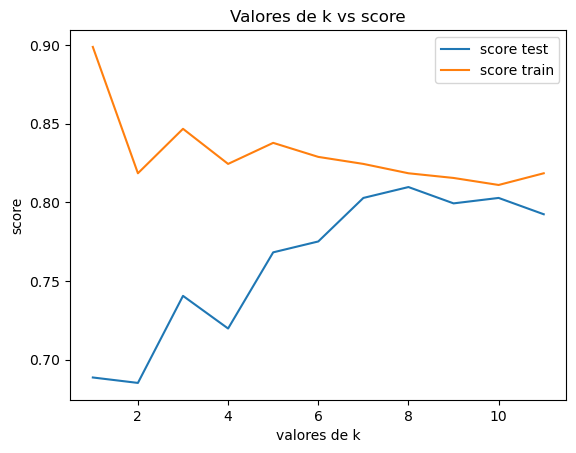

In [64]:
plt.plot(k_range,score_test,label="score test")
plt.plot(k_range,score_train,label="score train")
plt.xlabel("valores de k")
plt.ylabel("score")
plt.legend(loc='upper right')
plt.title("Valores de k vs score")
plt.show()

In [65]:
model_params={
    "knn_model":{
        "model":KNeighborsClassifier(), 
        "params":{ "n_neighbors":list(range(1,12))

        }
    }
    
            
}

In [66]:
models=[] # lista para guardar el accuracy de cada uno de los modelos
for model_name,mp in model_params.items():

    modelo=GridSearchCV(mp["model"],mp["params"],cv=5,n_jobs=-1,scoring="accuracy",verbose=0) #evaluamos con accuracy y partimos en 3 el conjunto de train
    
    modelo.fit(X_train,Y_train)
    models.append({
        "model":model_name,
        "best_score":modelo.best_score_,
        "best_params":modelo.best_params_
    })

In [67]:
df_models=pd.DataFrame(models).sort_values(by="best_score",ascending=False)
df_models

,model,best_score,best_params
0,knn_model,0.793167,{'n_neighbors': 9}


In [68]:
knn_model = KNeighborsClassifier(n_neighbors=9).fit(X_train,Y_train)
print("knn_model accuracy en train,",knn_model.score(X_train,Y_train))
print("knn_model accuracy en test,",knn_model.score(X_test,Y_test)) 

knn_model accuracy en train, 0.8154761904761905
knn_model accuracy en test, 0.7993079584775087
